In [10]:
import pickle
import pandas as pd
import seaborn as sns
import numpy as np



import matplotlib.pyplot as plt
from netective.utils import get_clusters
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

# Load the data
norm = 'raw'
num_nodes_values = range(1000, 5001, 1000)
density_values = [0.001, 0.005, 0.01]

dfs = []
for num_nodes in num_nodes_values:
    for density in density_values:
        with open(f'./synthetic_characterization_directed_output/scalar_{norm}_{density}_{num_nodes}.pkl', 'rb') as f:
            scalar_raw = pickle.load(f)

        df = pd.DataFrame.from_dict(scalar_raw).T
        # df = df.dropna(axis=1)
        dfs.append(df)

merged_df = pd.concat(dfs)
merged_df.dropna(axis=1, inplace=True, how='any')

In [11]:
from netective.utils import get_clusters
from sklearn.metrics import adjusted_rand_score

models = {
    'ba' : 0,
    'er' : 1,
    'ws' : 2,
    'dgm' : 3,
    'sf' : 4
    }

gs = [models[name.split('_')[0]] for name in merged_df.index]
clusters = get_clusters(merged_df.T.corr(), clust_num=5, map_ids=False)

all_undirected_props_score = adjusted_rand_score(gs, clusters)
print(f'with {len(merged_df.columns)} props: {all_undirected_props_score}')

with 64 props: 0.16837617252461018


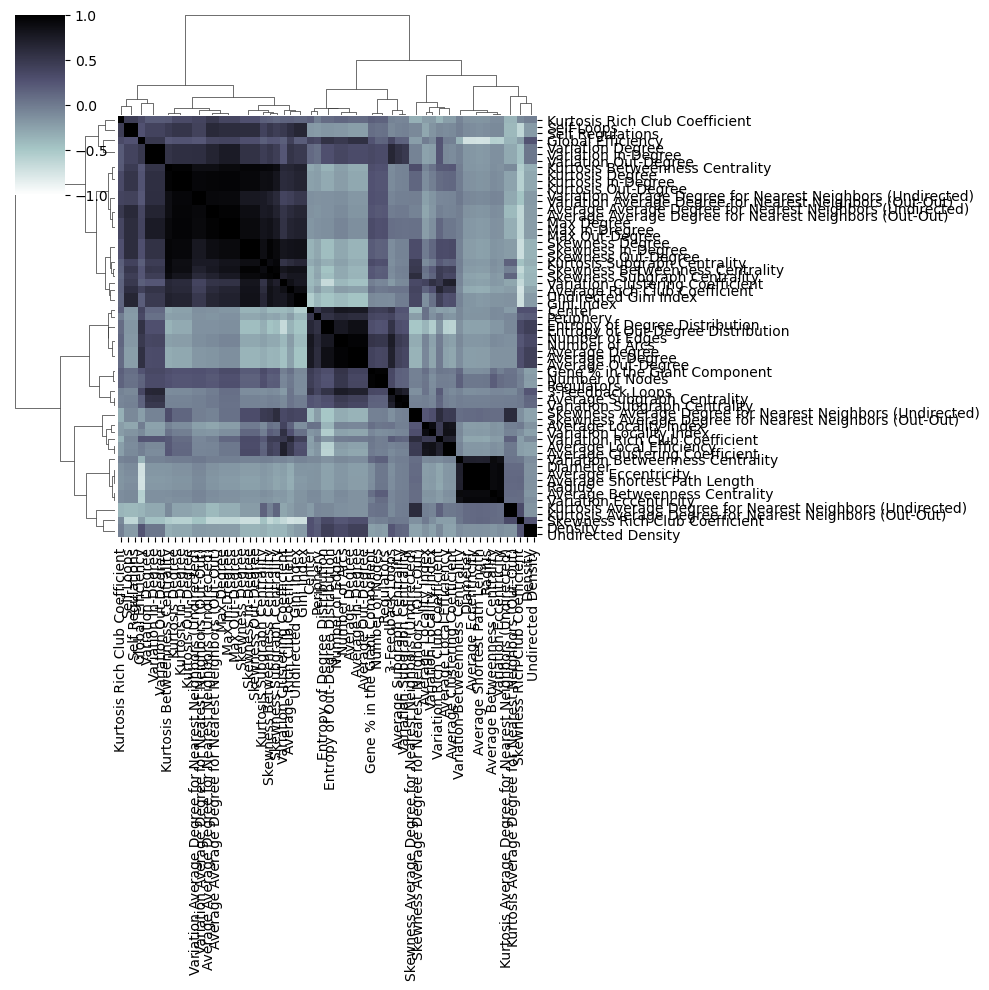

In [12]:
merged_df_corr = merged_df.corr()
merged_df_corr.dropna(axis=1, how='all', inplace=True)
merged_df_corr.dropna(axis=0, how='all', inplace=True)
ax = sns.clustermap(merged_df_corr,xticklabels=True, yticklabels=True, cmap='bone_r', vmin=-1, vmax=1, method='ward', metric='euclidean')

In [13]:
models = {prefix: i for i, prefix in enumerate(['ba', 'er', 'ws', 'dgm', 'sf'])}

def select_representative_feature(cluster, threshold, correlation_matrix):
    avg_corr_with_others = {}
    for feature1 in cluster:
        # Calculate the average correlation of feature1 with other features in the cluster
        avg_corr = sum([abs(correlation_matrix.loc[feature1, feature2]) for feature2 in cluster if feature1 != feature2]) / (len(cluster) - 1)
        avg_corr_with_others[feature1] = avg_corr

    # Select the feature with the highest average correlation
    representative_feature = max(avg_corr_with_others, key=avg_corr_with_others.get) if max(avg_corr_with_others.values()) >= threshold else None
    return representative_feature
        

        
# Select a threshold for correlation to remove redundant features
threshold = 0.8
distance_score = {}
distance_representative_features = {}
print(f'Features withing the same cluster with a correlation higher than {threshold} will be considered redundant.')
for distance in np.arange(0.05, 0.51, 0.05): # relative_max_intracluster_d
    # dist_mtrx = np.sqrt(2*(1 - abs(merged_df_corr.to_numpy())))
    dist_mtrx = 1 - abs(merged_df_corr.to_numpy())
    condensed_square_matrix = squareform(dist_mtrx)
    linkage_mtrx = linkage(condensed_square_matrix, method='ward', metric='euclidean')
    index = list(merged_df_corr.index)
    relative_max_intracluster_d = linkage_mtrx[:, 2].max()*distance # The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].
    cluster_vector = fcluster(linkage_mtrx, criterion="distance", t=relative_max_intracluster_d)
    clusters = {i: [] for i in cluster_vector}
    [clusters[cluster_vector[i]].append(index[i]) for i in range(len(cluster_vector))];
    clusters_with_redundancy = [v for k, v in clusters.items() if len(v) > 1]
    clusters_without_redundancy = [v for k, v in clusters.items() if len(v) == 1]
    props_without_redundancy = [item for sublist in clusters_without_redundancy for item in sublist]

    representative_features = props_without_redundancy.copy()
    for cluster in clusters_with_redundancy:
        representative_feature = select_representative_feature(cluster, threshold, merged_df_corr)
        if representative_feature is not None:
            representative_features.append(representative_feature)
        # else: # Ignored so we only keed those features that represent a bunch of features (are more informative?)
        #     representative_features.extend(cluster) # No representative feature was found, so we add all features in the cluster


    sub_corr = merged_df[representative_features].T.corr()

    gs = [models[name.split('_')[0]] for name in merged_df.index]
    clusters = get_clusters(sub_corr, clust_num=5, map_ids=False)
    rand_s = adjusted_rand_score(gs, clusters)
    print(f'max intracluster distance: {distance} with {len(representative_features)} features, {rand_s}')
    distance_score[distance] = rand_s
    distance_representative_features[distance] = representative_features
    

Features withing the same cluster with a correlation higher than 0.8 will be considered redundant.
max intracluster distance: 0.05 with 25 features, 0.1567300722555069
max intracluster distance: 0.1 with 21 features, 0.1567300722555069
max intracluster distance: 0.15000000000000002 with 17 features, 0.15087849568141498
max intracluster distance: 0.2 with 13 features, 0.160692361879843
max intracluster distance: 0.25 with 9 features, 0.160692361879843
max intracluster distance: 0.3 with 6 features, 0.35125885240829996
max intracluster distance: 0.35000000000000003 with 6 features, 0.35125885240829996
max intracluster distance: 0.4 with 4 features, 0.0939172848608578
max intracluster distance: 0.45 with 3 features, 0.5335578148084328
max intracluster distance: 0.5 with 3 features, 0.5335578148084328


    with 55 props: 0.30435837431576607

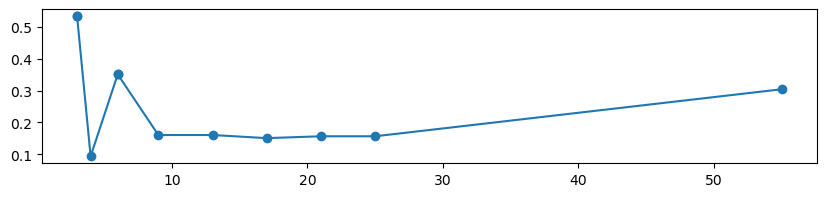

In [14]:
# plot distance vs score as scatter plot and line plot
plt.figure(figsize=(10, 2))
x = [len(x) for x in distance_representative_features.values()]
plt.plot([55]+x, [0.30435837431576607]+list(distance_score.values()), '-o')


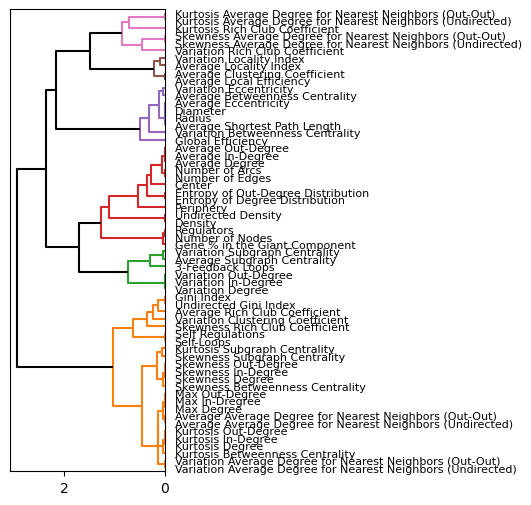

In [15]:
# dist_mtrx = np.sqrt(2*(1 - abs(merged_df_corr.to_numpy())))
dist_mtrx = 1 - abs(merged_df_corr.to_numpy())
condensed_square_matrix = squareform(dist_mtrx)
linkage_mtrx = linkage(condensed_square_matrix, method='ward', metric='euclidean')
index = list(merged_df_corr.index)
relative_max_intracluster_d = linkage_mtrx[:, 2].max()*0.5 # The distance between clusters Z[i, 0] and Z[i, 1] is given by Z[i, 2].
cluster_vector = fcluster(linkage_mtrx, criterion="distance", t=relative_max_intracluster_d)
clusters = {i: [] for i in cluster_vector}
[clusters[cluster_vector[i]].append(index[i]) for i in range(len(cluster_vector))];
clusters_with_redundancy = [v for k, v in clusters.items() if len(v) > 1]
clusters_without_redundancy = [v for k, v in clusters.items() if len(v) == 1]
props_without_redundancy = [item for sublist in clusters_without_redundancy for item in sublist]

# plot
plt.figure(figsize=(2, 6))
dendrogram(linkage_mtrx, orientation='left', labels=index, leaf_rotation=0, leaf_font_size=8, color_threshold=relative_max_intracluster_d, above_threshold_color='k');

In [16]:
distance_representative_features[0.5]

['Average Local Efficiency', 'Radius', 'Skewness In-Degree']

In [52]:
my_clust = """Average Degree
Entropy of Degree Distribution
Center
Global Efficiency
Periphery""".split('\n')

select_representative_feature(my_clust, 0.6, merged_df_corr)

'Entropy of Degree Distribution'

In [54]:
my_clust = """Kurtosis Average Degree for Nearest Neighbors (Undirected)
Skewness Average Degree for Nearest Neighbors (Undirected)""".split('\n')

select_representative_feature(my_clust, 0.5, merged_df_corr)

'Kurtosis Average Degree for Nearest Neighbors (Undirected)'

# Edges

In [149]:
with open('edges_0.01_5000.pkl', 'rb') as f:
    edges = pickle.load(f)

type_density_nodes_edges = []
for name, num_edges in edges.items():
    net_type, _, density, num_nodes, _ = name.split('_')
    type_density_nodes_edges.append([net_type, density, num_nodes, num_edges])

In [158]:
df.edges.max()

126143

edges    Axes(0.125,0.11;0.775x0.77)
dtype: object

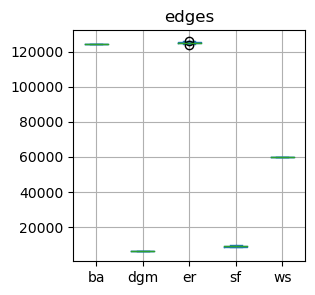

In [168]:
df = pd.DataFrame.from_records(type_density_nodes_edges, columns=['type', 'density', 'nodes', 'edges'], coerce_float=True)
df.plot.box(by='type', column=['edges'], grid=True, figsize=(3,3))

In [188]:
df

,type,density,nodes,edges
0,ba,0.01,5000,124375
1,er,0.01,5000,125192
2,ws,0.01,5000,60000
3,dgm,0.01,5000,6561
4,sf,0.01,5000,8541
...,...,...,...,...
495,ba,0.01,5000,124375
496,er,0.01,5000,125406
497,ws,0.01,5000,60000
498,dgm,0.01,5000,6561


nodes    Axes(0.125,0.11;0.775x0.77)
dtype: object

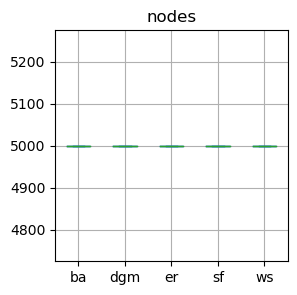

In [176]:
df.nodes = df.nodes.astype(int)
df.plot.box(by='type', column=['nodes'], grid=True, figsize=(3,3))

density    Axes(0.125,0.11;0.775x0.77)
dtype: object

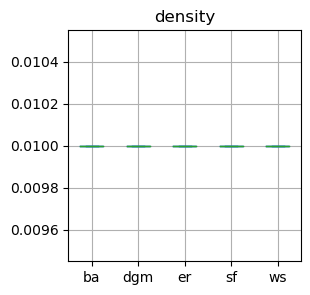

In [185]:
df.density = df.density.astype(float)
df.plot.box(by='type', column=['density'], grid=True, figsize=(3,3))